In [39]:
from PIL import Image
import torch
from torchvision.transforms.functional import to_tensor

# Input
EXT = "jpg"
IMAGES = ["Burke", "Patrick"]

# ImageNet normalization
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Constants
IMAGE_SIZE = 224 # Common CV standard
TRAIN_FRAC = 0.8 # Common industry standard
SEED = 0xDEADBEEF # Humorous personal standard
DOWNSAMPLER = Image.LANCZOS # Industry standard downsampler

for IMG in IMAGES:
    img = Image.open(f"./{IMG}.{EXT}").convert("RGB").resize((IMAGE_SIZE, IMAGE_SIZE), resample=DOWNSAMPLER)
    img.save(f"./{IMG}-downsampled.{EXT}")
    ten = (to_tensor(img).float() - MEAN) / STD
    torch.save(ten, f"./{IMG}.pt")

In [40]:
import os
import torchvision.models as models
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"cwd is {os.getcwd()}")

file_name_model = "First_long_local_trained/model_epoch_45.pt"
file_name_classifier ="First_long_local_trained/classifier_epoch_45.pt"

if os.path.exists(file_name_model):
    print ("File path exists")
else:
    print("File not found")

trained_model = torch.load(file_name_model, weights_only=False).to(DEVICE)
trained_classifier = torch.load(file_name_classifier, weights_only=False).to(DEVICE)

trained_model.eval()
trained_classifier.eval()
for IMG in IMAGES:
    X = torch.load(f"{IMG}.pt").unsqueeze(0).to(DEVICE)
    y_hat = trained_classifier(trained_model(X)).to(DEVICE)
    print(f"IMAGE: {IMG}.{EXT} ({y_hat.tolist()})")


cwd is /home/patrick/Graduate/Year 1/Summer2/EECE5644/Final/FinalProject
File path exists
IMAGE: Burke.jpg ([[-12.356328010559082, 13.462261199951172]])
IMAGE: Patrick.jpg ([[-29.080446243286133, 31.685298919677734]])


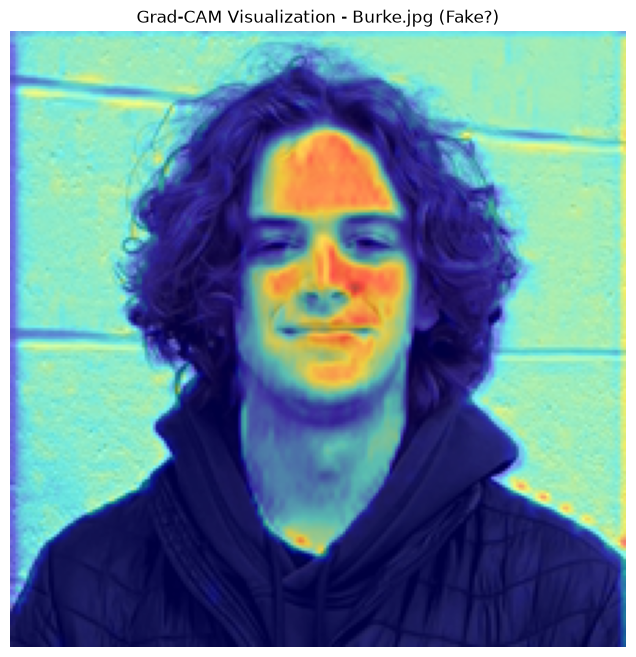

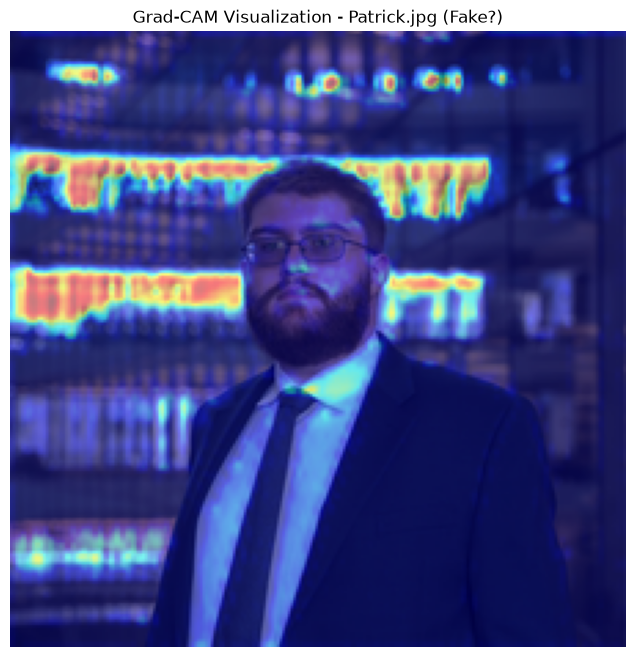

In [42]:
from torchvision.transforms.functional import to_pil_image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np
import random

def to_image(x):
    x = x * STD + MEAN
    x = np.clip(x.cpu().numpy(), 0, 1).astype(np.float32)
    x = np.transpose(x, (1, 2, 0))
    return x

target_layers = trained_model.features[0:3]

trained_model.eval()
with GradCAM(model=trained_model, target_layers=target_layers) as cam:
    for IMG in IMAGES:
        X = torch.load(f"{IMG}.pt").unsqueeze(0)
        
        grayscale_cam = cam(
            input_tensor=X, 
            targets=[ClassifierOutputTarget(1)],
            eigen_smooth=False,
            aug_smooth=False
        )
        grayscale_cam = grayscale_cam[0, :]
        
        visualization = show_cam_on_image(to_image(X.squeeze(0)), grayscale_cam, use_rgb=True)
        
        plt.figure(figsize=(10, 8))
        plt.imshow(visualization)
        plt.title(f'Grad-CAM Visualization - {IMG}.{EXT} (Fake?)')
        plt.axis('off')
        plt.show()